In [1]:
import pandas as pd
import numpy as np
import os

seeds = [42,0,1,2,3]
seed = 42

dges_results = {}
original_dge = pd.read_csv('../DGE/DGE_results/DGE_Origin.csv')
dges_results['Origin'] = original_dge
synthetic_datasets = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",
                      f"synthpop_{seed}",f"tvae_{seed}"]

for synthetic_dataset in synthetic_datasets:
    try:
        dge_syn_result = pd.read_csv(f'../DGE/DGE_results/Seed_{seed}/DGE_{synthetic_dataset}.csv')
        dges_results[synthetic_dataset] = dge_syn_result
    except Exception as err:
        print(f"{synthetic_dataset}: {err}")

tvae_42: [Errno 2] No such file or directory: '../DGE/DGE_results/Seed_42/DGE_tvae_42.csv'


In [2]:
import gseapy as gp

os.makedirs(f'Seed_{seed}', exist_ok = True)
def get_safe_df(df, status_col='Status'):
    safe_df = df[df[status_col] == 'ok'].copy()
    return safe_df

  
hallmarks_gmt = "h.all.v2025.1.Hs.symbols.gmt"
GSEA_overall= {}
for name, degs in dges_results.items():
    print(f"----GSEA {name}----")
    safe_df = get_safe_df(degs)
    # safe_df = degs
    safe_df['Rank_Score'] = np.sign(safe_df['Log2FC'])*(-np.log10(safe_df['P_value']))
    ranked_results_df = safe_df.sort_values(by="Rank_Score", ascending = False)
    rnk = ranked_results_df[["Gene","Rank_Score"]].set_index("Gene")
    pre_res = gp.prerank(rnk=rnk,
                         gene_sets=hallmarks_gmt,
                         threads=32,
                         permutation_num=10000, # reduce number to speed up testing
                         outdir=None, # don't write to disk
                         seed=seed,
                         verbose=False)
    prerank_overall = pre_res.res2d
    # prerank_overall.to_csv(f"Seed_{seed}/GSEA_{name}.csv",index = False)
    GSEA_overall[name] = prerank_overall

2025-12-11 22:48:16,199 [WARNING] Duplicated values found in preranked stats: 75.93% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


----GSEA Origin----


2025-12-11 22:48:44,663 [WARNING] Duplicated values found in preranked stats: 81.11% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


----GSEA avatarsk5_42----


2025-12-11 22:49:08,184 [WARNING] Duplicated values found in preranked stats: 75.19% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


...

----GSEA ctgan_42----


2025-12-11 22:49:54,050 [WARNING] Duplicated values found in preranked stats: 81.68% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


----GSEA gaussiancopula_42----


2025-12-11 22:50:15,896 [WARNING] Duplicated values found in preranked stats: 79.82% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


----GSEA synthpop_42----


In [3]:
from Utils import compute_jaccard_indices, extract_significances, spearman_across_datasets

orig_paths = extract_significances(GSEA_overall["Origin"], term_col="Term", adj_p_col="FDR q-val", threshold=0.25)
synth_paths_dict = {k: extract_significances(v, term_col="Term", adj_p_col="FDR q-val", threshold=0.25)
                     for k, v in GSEA_overall.items() if k != "Origin"}

jaccard_df = compute_jaccard_indices(orig_paths, synth_paths_dict)
jaccard_df

,Dataset,Original_count,Synthetic_count,Intersection,Union,Jaccard
0,avatarsk5_42,7,37,6,38,0.157895
1,avatarsk10_42,7,39,6,40,0.150000
2,ctgan_42,7,0,0,7,0.000000
3,gaussiancopula_42,7,6,4,9,0.444444
4,synthpop_42,7,10,3,14,0.214286


In [4]:
GSEA_Sig = {}
for data, dfgsea in GSEA_overall.items():
    dfgsea_sig = dfgsea[dfgsea['Term'].isin(orig_paths)]
    GSEA_Sig[data] = dfgsea_sig
spearman_df, _ = spearman_across_datasets(
    gsea_overall = GSEA_Sig,
    origin = "Origin",
    term_col = "Term",
    score_col = "NES",
    min_terms = 3)
spearman_df

,Dataset,Spearman_rho,p_value,n_terms_used
0,avatarsk10_42,0.571429,0.180202,7
1,avatarsk5_42,0.750000,0.052181,7
2,ctgan_42,0.821429,0.023449,7
3,gaussiancopula_42,0.714286,0.071344,7
4,synthpop_42,0.357143,0.431611,7


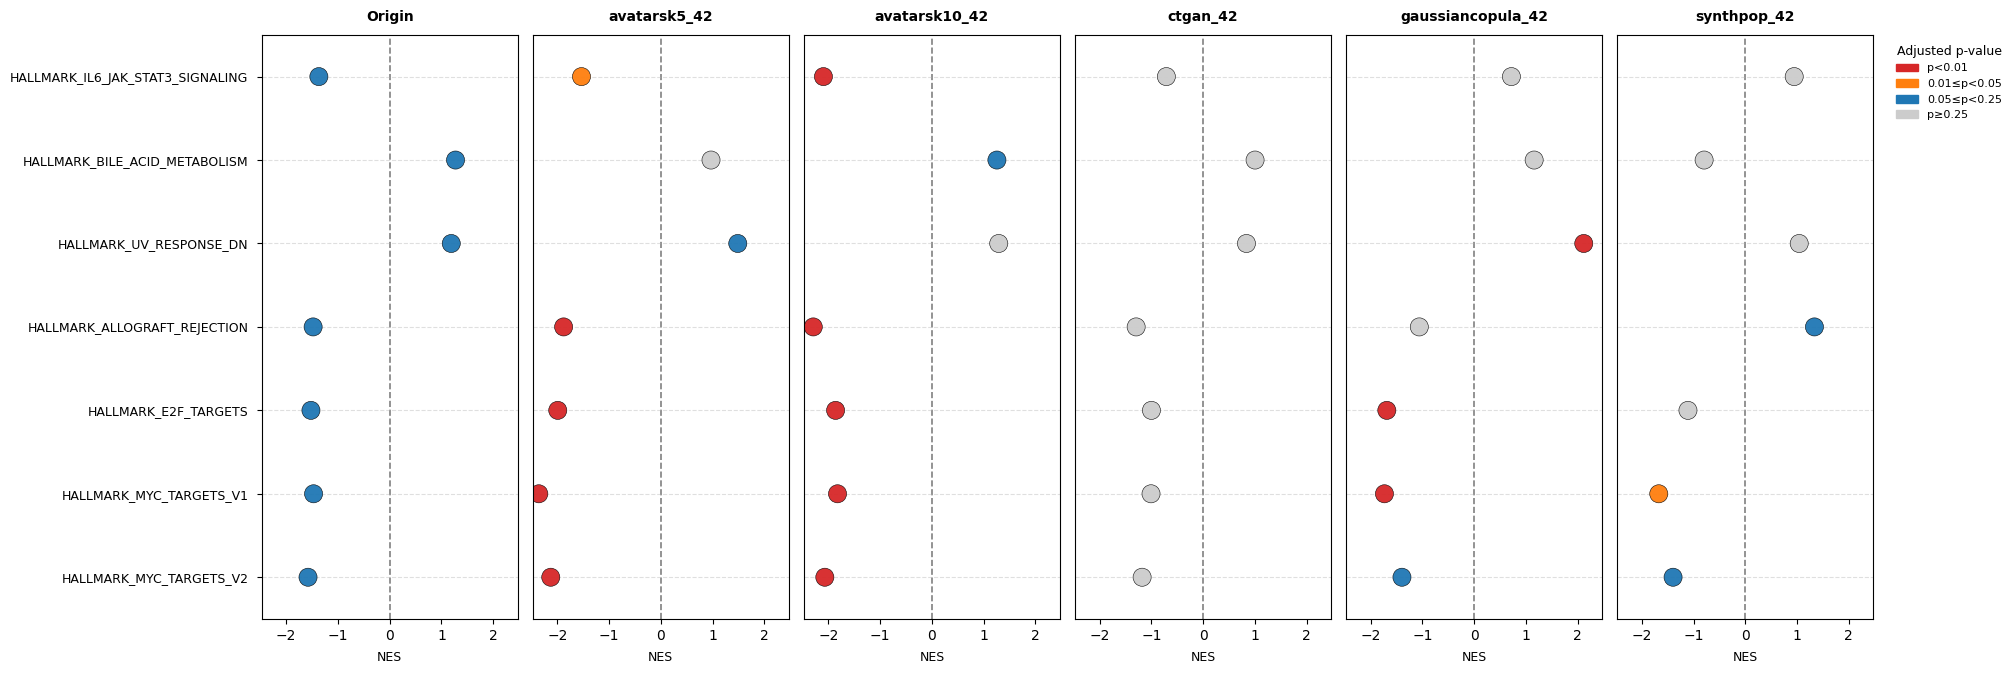

In [6]:
from GSEA import plot_pathway

ref_pathway_list = orig_paths
# highlight_pathways = ['HALLMARK_IL6_JAK_STAT3_SIGNALING']

# Call the plotting function
fig, df_used = plot_pathway(
    ssGSEA_comparison=GSEA_Sig,
    ref_pathway_list=ref_pathway_list,
    highlight_pathways=[],
    origin_name = "Origin",
    term_col = "Term",
    pval_col = "FDR q-val",
    diff_col = "NES",
    show=True,
    save_path=None
)
# plt.show()